# Python EDA Project – World Real Estate Analysis  
### Data Analysis Bootcamp – General Assembly  
This project is part of the Data Analysis Bootcamp at General Assembly.  
The objective is to perform a full Exploratory Data Analysis (EDA) using Python and Pandas, following the complete data analytics workflow: data cleaning, exploration, visualization, and insight generation.

## Dataset Source  
**World's Real Estate Data (147K listings)**  
https://www.kaggle.com/datasets/toriqulstu/worlds-real-estate-data147k  

> To run this notebook, download the CSV from the link above and place it in the same directory as this notebook.

## Data Dictionary

| Column | Type | Description |
|--------|------|-------------|
| `title` | str | Listing title (e.g. "3 room apartment 120 m² in Antalya, Turkey") |
| `country` | str | Country where the property is located |
| `location` | str | Full location string (region, city, country) |
| `building_construction_year` | float | Year the building was constructed |
| `building_total_floors` | float | Total number of floors in the building |
| `apartment_floor` | float | Floor level of the specific unit |
| `apartment_rooms` | float | Total number of rooms |
| `apartment_bedrooms` | float | Number of bedrooms |
| `apartment_bathrooms` | float | Number of bathrooms |
| `apartment_total_area` | str → float | Total property area in m² |
| `apartment_living_area` | str → float | Living/usable area in m² |
| `price_in_USD` | float | Listing price in US Dollars |
| `image` | str | URL pointing to the property listing image (expired) |
| `url` | str | URL pointing to the original property listing page (expired) |
| `property_type` | str | Extracted property type (apartment, villa, studio, etc.) |
| `price_per_sqm` | float | Property price per square meter in USD, calculated as `price_in_USD / apartment_total_area`. Used to compare property value across countries and sizes fairly. |
| `building_age` | float | Age of the building in years as of 2026, calculated as `2026 - building_construction_year`. Only available for rows where construction year is present. |

## Project Objective  
The main goal is to understand what factors drive real estate prices globally. We aim to answer the following business questions:

1. **Which countries have the highest and lowest median property prices?**
2. **Which property types are the most expensive on average?**
3. **Is there a relationship between living area and price?**
4. **Do newer buildings cost more than older ones?**

## 1. Data Loading

We start by importing the necessary libraries and loading the dataset into a Pandas DataFrame.

In [1]:
import pandas as pd

# Load the dataset from CSV
path = 'world_real_estate_data(147k).csv'
df = pd.read_csv(path)

# url and image will not be dropped and will be treated as a unique id
# we get different results if we dropped them if we removed the duplicate
#df.drop(columns=['image', 'url'], inplace=True)

# Quick preview
df.head()

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",NaN,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888...,https://realting.com/property-for-sale/turkey/...
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,NaN,NaN,NaN,NaN,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/679...,https://realting.com/property-for-sale/turkey/...
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",NaN,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a11...,https://realting.com/property-for-sale/turkey/...
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e06...,https://realting.com/property-for-sale/thailan...
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2...,https://realting.com/property-for-sale/thailan...


## 2. Initial Data Exploration

Before cleaning, we inspect the structure of the data: column types, shape, basic statistics, and missing value percentages.  
This helps us understand the scale of the issues we need to address.

In [2]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       147536 non-null  str    
 1   country                     147406 non-null  str    
 2   location                    147405 non-null  str    
 3   building_construction_year  64719 non-null   float64
 4   building_total_floors       68224 non-null   float64
 5   apartment_floor             54592 non-null   float64
 6   apartment_rooms             74178 non-null   float64
 7   apartment_bedrooms          36982 non-null   float64
 8   apartment_bathrooms         55973 non-null   float64
 9   apartment_total_area        141796 non-null  str    
 10  apartment_living_area       27712 non-null   str    
 11  price_in_USD                144961 non-null  float64
 12  image                       147536 non-null  str    
 13  url                      

In [3]:
# Total rows and columns in the dataset
print('Shape:', df.shape)

Shape: (147536, 14)


In [4]:
# Summary statistics for numerical columns
# Notable: min values of -1 (floors/rooms) and year=1 suggest data entry errors
df.describe()

,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,price_in_USD
count,64719.000000,68224.000000,54592.000000,74178.000000,36982.000000,55973.000000,1.449610e+05
mean,1996.921754,8.575692,5.791709,2.572097,2.289222,1.364229,4.121722e+05
std,157.527635,8.356781,5.541368,1.319545,18.276913,0.745019,8.420984e+05
min,1.000000,-1.000000,-2.000000,-1.000000,-1.000000,1.000000,0.000000e+00
25%,2004.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.054200e+05
50%,2021.000000,5.000000,4.000000,2.000000,2.000000,1.000000,1.902120e+05
75%,2024.000000,14.000000,8.000000,3.000000,3.000000,2.000000,3.989300e+05
max,2316.000000,124.000000,202.000000,124.000000,2009.000000,43.000000,3.060283e+07


In [5]:
# percentage of null values in our columns 
null_percentages = df.isnull().mean() * 100

print("Null Percentages per Column:")
print(null_percentages)

Null Percentages per Column:
title                          0.000000
country                        0.088114
location                       0.088792
building_construction_year    56.133418
building_total_floors         53.757727
apartment_floor               62.997506
apartment_rooms               49.722102
apartment_bedrooms            74.933576
apartment_bathrooms           62.061463
apartment_total_area           3.890576
apartment_living_area         81.216788
price_in_USD                   1.745337
image                          0.000000
url                            0.000000
dtype: float64


## 3. Data Cleaning

This section systematically addresses the quality issues found during exploration:

- **3a.** Check for and remove duplicate rows  
- **3b.** Fix missing country values  
- **3c.** Extract property_type from the listing title  
- **3d.** Convert area columns from strings to numeric  
- **3e.** Remove rows with invalid/impossible values  
- **3f.** Drop rows with missing prices (our key variable)

### 3a. Checking for Duplicates

In [6]:
# Check for fully duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# Drop duplicates if any exist
df = df.drop_duplicates()
print('Shape after dropping duplicates:', df.shape)

Duplicate rows: 0
Shape after dropping duplicates: (147536, 14)


### 3b. Fixing Missing Country Values

~130 rows have NaN in the country column. Since every listing title ends with the country name (e.g. "3 room apartment ... in, Turkey"), we can recover the country by extracting the last segment after the final comma.

In [7]:
# all country names in this data are unique there are no duplicates or typo except for 'nan'
# we need to remove it or compute it from the 'title' column if it exist
df['country'].unique()

<StringArray>
[         'Turkey',        'Thailand',         'Georgia',      'Montenegro',
 'Northern Cyprus',       'Lithuania',         'Belarus',             'UAE',
  'Czech Republic',      'Uzbekistan',               nan,          'Greece',
          'Serbia',           'Italy',         'Hungary',          'Russia',
         'Finland',          'Poland',         'Austria',           'Spain',
          'Latvia',        'Portugal',   'United States',         'Armenia',
         'Croatia',          'Cyprus',       'Australia',       'Indonesia']
Length: 28, dtype: str

In [8]:
# we want to see the rows where 'nan' is the country name
df[df['country'].isna()]

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
3772,"3 room apartment 180 m² in, Turkey",NaN,NaN,NaN,3.0,NaN,4.0,3.0,NaN,180 m²,NaN,528267.0,https://realting.com/uploads/bigSlider/192/45f...,https://realting.com/property-for-sale/turkey/...
3775,"3 room apartment 160 m² in, Turkey",NaN,NaN,NaN,3.0,NaN,4.0,3.0,NaN,160 m²,NaN,647699.0,https://realting.com/uploads/bigSlider/f05/5fa...,https://realting.com/property-for-sale/turkey/...
3863,"4 room apartment 165 m² in, Turkey",NaN,NaN,2023.0,5.0,2.0,5.0,4.0,3.0,165 m²,157 m²,581507.0,https://realting.com/uploads/bigSlider/ef2/9a3...,https://realting.com/property-for-sale/turkey/...
3936,"3 room apartment 350 m² in, Turkey",NaN,NaN,NaN,3.0,NaN,4.0,3.0,NaN,350 m²,NaN,809624.0,https://realting.com/uploads/bigSlider/827/3d8...,https://realting.com/property-for-sale/turkey/...
4132,"3 room apartment 254 m² in, Turkey",NaN,NaN,NaN,4.0,NaN,4.0,3.0,NaN,254 m²,NaN,755649.0,https://realting.com/uploads/bigSlider/808/01a...,https://realting.com/property-for-sale/turkey/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142504,"3 room apartment 160 m² in, Italy",NaN,NaN,NaN,NaN,NaN,4.0,3.0,NaN,160 m²,NaN,765071.0,https://realting.com/uploads/bigSlider/530/8ca...,https://realting.com/property-for-sale/italy/r...
142923,"3 room apartment 103 m² in, Greece",NaN,NaN,2023.0,1.0,1.0,4.0,3.0,1.0,103 m²,NaN,382535.0,https://realting.com/uploads/bigSlider/836/9d4...,https://realting.com/property-for-sale/greece/...
144095,"1 room apartment 54 m² in, Greece",NaN,NaN,NaN,7.0,NaN,2.0,1.0,NaN,54 m²,NaN,244830.0,https://realting.com/uploads/bigSlider/9bf/9ce...,https://realting.com/property-for-sale/greece/...
144103,"3 room apartment 150 m² in, Greece",NaN,NaN,1980.0,1.0,3.0,4.0,3.0,2.0,150 m²,NaN,273240.0,https://realting.com/uploads/bigSlider/8ee/666...,https://realting.com/property-for-sale/greece/...


In [9]:
# remove any extra space from the 'title' column
df['title'] = df['title'].str.strip()

In [10]:
# Extract the text after the last comma in the title -> gives us the country
df['country_from_title'] = (
    df['title']
    .str.extract(r',\s*(.*)$', expand=False)
    .str.strip()
)
# Fill NaN in 'country' using extracted value
df['country'] = df['country'].fillna(df['country_from_title'])
df.drop(columns=['country_from_title'], inplace=True)

print('Remaining country NaNs:', df['country'].isna().sum())
print('Countries:', df['country'].unique())

Remaining country NaNs: 0
Countries: <StringArray>
[         'Turkey',        'Thailand',         'Georgia',      'Montenegro',
 'Northern Cyprus',       'Lithuania',         'Belarus',             'UAE',
  'Czech Republic',      'Uzbekistan',          'Greece',          'Serbia',
           'Italy',         'Hungary',          'Russia',         'Finland',
          'Poland',         'Austria',           'Spain',          'Latvia',
        'Portugal',   'United States',         'Armenia',         'Croatia',
          'Cyprus',       'Australia',       'Indonesia']
Length: 27, dtype: str


In [11]:
df['country'].value_counts()

country
Turkey             25757
Hungary            22346
Russia             18491
Spain              14939
Belarus            14257
Greece             12438
Montenegro         10702
Italy               3337
Georgia             3292
UAE                 2675
Lithuania           2567
Latvia              2295
Thailand            2224
Portugal            2103
Croatia             2032
Uzbekistan          1952
Finland             1751
Czech Republic      1371
Poland              1210
Northern Cyprus      750
United States        414
Austria              237
Armenia              110
Serbia               104
Indonesia            102
Cyprus                79
Australia              1
Name: count, dtype: int64

### 3c. Extracting Property Type from Title

The dataset has no dedicated property_type column. We engineer one by parsing the listing title:
1. If the title contains the word room (e.g. "3 room apartment"), we take the word immediately after it.
2. Otherwise, we fall back to the first word of the title (e.g. "Penthouse", "Villa").
3. We filter out invalid extractions like numbers and stop-words like 'in'.

In [12]:
df['property_type'] = (
    df['title']
    .str.extract(r'room\s+(\w+)', expand=False)
    .str.lower()
)
print(df['property_type'].unique())
#  we have some numbers(strings that are numbers) in our property type column

<StringArray>
['apartment',     'villa',    'studio',        '74',        '96',         nan,
     'house',     'condo',        '75',        'in',
 ...
       '197',       '408',       '187',   'cottage',        '24',    'duplex',
         '6',       '659',       '149',       '294']
Length: 246, dtype: str


In [13]:
filtered_df = df[df['property_type'].str.contains('133', case=False, na=False)]
filtered_df.head()
# looking at the patterns we can extract the correct property type 

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url,property_type
40070,"House 1 bathroom 133 m² in Zsambek, Hungary",Hungary,"Zsambek, Central Hungary, Budakeszi jaras, Pes...",1965.0,2.0,NaN,NaN,NaN,NaN,133 m²,NaN,92894.0,https://realting.com/uploads/bigSlider/708/cf0...,https://realting.com/property-for-sale/hungary...,133
143041,"Penthouse 1 bedroom 133 m² in Karavas, Norther...",Northern Cyprus,"Karavas, Kyrenia, Girne (Kyrenia) District, No...",NaN,1.0,1.0,2.0,1.0,2.0,133 m²,123 m²,242573.0,https://realting.com/uploads/bigSlider/fa2/bf9...,https://realting.com/property-for-sale/norther...,133
143721,"Penthouse 1 bedroom 133 m² in Trimithi, Northe...",Northern Cyprus,"Trimithi, Girne (Kyrenia) District, Northern C...",2026.0,1.0,1.0,2.0,1.0,2.0,133 m²,123 m²,255834.0,https://realting.com/uploads/bigSlider/99e/c93...,https://realting.com/property-for-sale/norther...,133
143724,"Penthouse 1 bedroom 133 m² in Tatlisu, Norther...",Northern Cyprus,"Tatlisu, Famagusta, Gazimağusa District, North...",2025.0,2.0,NaN,2.0,1.0,1.0,133 m²,80 m²,242637.0,https://realting.com/uploads/bigSlider/c24/f8d...,https://realting.com/property-for-sale/norther...,133


In [14]:
# extract after 'room' (if exists)
df['property_type'] = df['title'].str.extract(r'room\s+(\w+)', expand=False)

# fill missing with first word from title
first_word = df['title'].str.split().str[0]

# replace numeric values with first word
df['property_type'] = df['property_type'].where(~df['property_type'].str.isnumeric(), first_word)

#lowercase everything
df['property_type'] = df['property_type'].str.lower()

df

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url,property_type
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",NaN,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888...,https://realting.com/property-for-sale/turkey/...,apartment
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,NaN,NaN,NaN,NaN,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/679...,https://realting.com/property-for-sale/turkey/...,villa
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",NaN,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a11...,https://realting.com/property-for-sale/turkey/...,apartment
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e06...,https://realting.com/property-for-sale/thailan...,apartment
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2...,https://realting.com/property-for-sale/thailan...,apartment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147531,"5 room apartment 310 m² in Gazipasa, Turkey",Turkey,"Mediterranean Region, Gazipasa, Turkey",NaN,NaN,NaN,NaN,5.0,NaN,310 m²,NaN,597810.0,https://realting.com/uploads/bigSlider/e4a/67f...,https://realting.com/property-for-sale/turkey/...,apartment
147532,"4 room apartment 192 m² in Marmara Region, Turkey",Turkey,"Marmara Region, Turkey",2023.0,5.0,NaN,5.0,4.0,2.0,192 m²,151 m²,637195.0,https://realting.com/uploads/bigSlider/93e/5c6...,https://realting.com/property-for-sale/turkey/...,apartment
147533,"2 room apartment in Marmara Region, Turkey",Turkey,"Marmara Region, Turkey",NaN,NaN,NaN,3.0,2.0,2.0,NaN,84 m²,477146.0,https://realting.com/uploads/bigSlider/4ae/9d8...,https://realting.com/property-for-sale/turkey/...,apartment
147534,"Apartment in Akarca, Turkey",Turkey,"Akarca, Central Anatolia Region, Turkey",2023.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,819163.0,https://realting.com/uploads/bigSlider/164/7e6...,https://realting.com/property-for-sale/turkey/...,NaN


In [15]:
# check again for property type
df['property_type'].unique()
# we still have some issues with "in" and "Nan" as our property type

<StringArray>
[ 'apartment',      'villa',     'studio',  'penthouse',          nan,
      'house',      'condo',         'in',       'room', 'multilevel',
  'townhouse',    'cottage',     'duplex',   'bungalow',    'mansion']
Length: 15, dtype: str

In [16]:
filtered_df = df[df['property_type'].str.contains('in', case=False, na=False)]
filtered_df.head()
# again we look at the patterns and repeat the extraction process

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url,property_type
1932,"Multilevel apartments 1 bedroom in Silivri, T...",Turkey,"Silivri, Marmara Region, Turkey",2024.0,14.0,NaN,2.0,1.0,1.0,NaN,NaN,180000.0,https://realting.com/uploads/bigSlider/3f5/5a3...,https://realting.com/property-for-sale/turkey/...,in
3462,"Multilevel apartments 1 bedroom in Bakirkoey,...",Turkey,"Bakirkoey, Marmara Region, Turkey",2022.0,14.0,NaN,2.0,1.0,1.0,NaN,NaN,489096.0,https://realting.com/uploads/bigSlider/261/ae4...,https://realting.com/property-for-sale/turkey/...,in
3708,"Multilevel apartments 1 bedroom in Bakirkoey,...",Turkey,"Bakirkoey, Marmara Region, Turkey",2022.0,NaN,3.0,2.0,1.0,1.0,NaN,NaN,430651.0,https://realting.com/uploads/bigSlider/1f8/e83...,https://realting.com/property-for-sale/turkey/...,in
4852,Multilevel apartments 1 bedroom in Marmara Re...,Turkey,"Marmara Region, Turkey",2023.0,14.0,3.0,2.0,1.0,1.0,NaN,NaN,231222.0,https://realting.com/uploads/bigSlider/e14/469...,https://realting.com/property-for-sale/turkey/...,in
9462,Multilevel apartments 1 bedroom in Ayazaga Ma...,Turkey,"Marmara Region, Ayazaga Mahallesi, Turkey",2022.0,6.0,NaN,2.0,1.0,1.0,NaN,NaN,618327.0,https://realting.com/uploads/bigSlider/690/689...,https://realting.com/property-for-sale/turkey/...,in


In [17]:
# extract after 'room' (if exists)
df['property_type'] = df['title'].str.extract(r'room\s+(\w+)', expand=False)

# fill missing with first word from title
first_word = df['title'].str.split().str[0]

# replace unwanted values (numbers or 'in') with first word
unwanted = ['in']
df['property_type'] = df['property_type'].where(
    ~(df['property_type'].str.isnumeric() | df['property_type'].isin(unwanted)),
    first_word
)

# lowercase everything
df['property_type'] = df['property_type'].str.lower()

In [18]:
df['property_type'].unique()
# now we deal with the "Nan" property type 

<StringArray>
[ 'apartment',      'villa',     'studio',  'penthouse',          nan,
      'house',      'condo', 'multilevel',       'room',  'townhouse',
    'cottage',     'duplex',   'bungalow',    'mansion']
Length: 14, dtype: str

In [19]:
# This returns only the rows where property_type is missing
null_df = df[df['property_type'].isna()]
null_df.head()

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url,property_type
11,"Apartment 48 m² in Herceg Novi, Montenegro",Montenegro,"Herceg Novi, Montenegro",NaN,4.0,4.0,NaN,NaN,NaN,48 m²,NaN,297706.0,https://realting.com/uploads/bigSlider/18c/290...,https://realting.com/property-for-sale/montene...,NaN
13,"Cottage 555 m² in Haranski sielski Saviet, Bel...",Belarus,"Minsk Region, Haranski sielski Saviet, Minsk D...",2017.0,3.0,NaN,NaN,NaN,NaN,555 m²,NaN,295000.0,https://realting.com/uploads/bigSlider/1c6/9af...,https://realting.com/property-for-sale/belarus...,NaN
17,"Penthouse 3 bedrooms 150 m² in Alanya, Turkey",Turkey,"Mediterranean Region, Sekerhane Mahallesi, Ala...",2022.0,5.0,NaN,4.0,3.0,2.0,150 m²,135 m²,260863.0,https://realting.com/uploads/bigSlider/66a/f86...,https://realting.com/property-for-sale/turkey/...,NaN
21,"Apartment in Akarca, Turkey",Turkey,"Akarca, Central Anatolia Region, Turkey",2022.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,304177.0,https://realting.com/uploads/bigSlider/909/2f9...,https://realting.com/property-for-sale/turkey/...,NaN
39,"Apartment 210 m² in Istanbul, Turkey",Turkey,"Marmara Region, Istanbul, Turkey",NaN,NaN,NaN,NaN,NaN,NaN,210 m²,NaN,337000.0,https://realting.com/uploads/bigSlider/29c/864...,https://realting.com/property-for-sale/turkey/...,NaN


In [20]:
# we repat the extraction process one more time

df['first_word'] = df['title'].str.strip().str.split().str[0]

df['first_word'] = df['first_word'].where(
    ~df['first_word'].str.isnumeric()
)

df['property_type'] = df['property_type'].fillna(df['first_word'])

df['property_type'] = df['property_type'].str.lower()

df.drop(columns=['first_word'], inplace=True)

In [21]:
df['property_type'].unique()
# we still have "Nan" as our property type so we look again at the patterns 

<StringArray>
[ 'apartment',      'villa',     'studio',  'penthouse',      'house',
    'cottage',      'condo', 'multilevel',       'room',  'townhouse',
     'castle',    'mansion',     'duplex',   'bungalow',     'chalet',
    'triplex',          nan]
Length: 17, dtype: str

In [22]:
# there is no property type to extract from the title 
null_df = df[df['property_type'].isna()]
null_df.head()

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url,property_type
140828,"56 m² in Nizhny Novgorod, Russia",Russia,"Volga Federal District, Nizhny Novgorod, Russia",NaN,1.0,NaN,NaN,NaN,NaN,56 m²,NaN,52190.0,https://realting.com/uploads/bigSlider/b45/c81...,https://realting.com/property-for-sale/russia/...,NaN
140843,"62 m² in Nizhny Novgorod, Russia",Russia,"Volga Federal District, Nizhny Novgorod, Russia",NaN,1.0,NaN,NaN,NaN,NaN,62 m²,NaN,47160.0,https://realting.com/uploads/bigSlider/f05/b47...,https://realting.com/property-for-sale/russia/...,NaN
140848,"140 m² in Nizhny Novgorod, Russia",Russia,"Volga Federal District, Nizhny Novgorod, Russia",NaN,2.0,NaN,NaN,NaN,NaN,140 m²,NaN,47160.0,https://realting.com/uploads/bigSlider/e5d/3c9...,https://realting.com/property-for-sale/russia/...,NaN
140897,"50 m² in Nizhny Novgorod, Russia",Russia,"Volga Federal District, Nizhny Novgorod, Russia",NaN,1.0,NaN,NaN,NaN,NaN,50 m²,NaN,36649.0,https://realting.com/uploads/bigSlider/264/59a...,https://realting.com/property-for-sale/russia/...,NaN
140908,"40 m² in Nizhny Novgorod, Russia",Russia,"Volga Federal District, Nizhny Novgorod, Russia",NaN,1.0,NaN,NaN,NaN,NaN,40 m²,NaN,31440.0,https://realting.com/uploads/bigSlider/68a/f0b...,https://realting.com/property-for-sale/russia/...,NaN


In [23]:
# we cheack how many of those with no property type (Nan) are left in our data
df['property_type'].isna().value_counts()

# the difference is small so we decided to drop them

property_type
False    147526
True         10
Name: count, dtype: int64

In [24]:
df = df.dropna(subset=['property_type'])
df['property_type'].isna().value_counts()

property_type
False    147526
Name: count, dtype: int64

In [25]:
# now our property type is clean
df['property_type'].unique()

<StringArray>
[ 'apartment',      'villa',     'studio',  'penthouse',      'house',
    'cottage',      'condo', 'multilevel',       'room',  'townhouse',
     'castle',    'mansion',     'duplex',   'bungalow',     'chalet',
    'triplex']
Length: 16, dtype: str

### 3d. Converting Area Columns to Numeric

apartment_total_area and apartment_living_area are stored as strings like "120 m²". We strip the " m²" suffix and convert to float so we can use them in calculations.

In [26]:
# Remove ' m²' suffix and convert to float
df['apartment_total_area'] = (
    df['apartment_total_area']
    .str.replace(r'[^\d.]', '', regex=True) # remove everything that is not a digit or decimal point
    .astype(float)
)

df['apartment_living_area'] = (
    df['apartment_living_area']
    .str.replace(r'[^\d.]', '', regex=True) # remove everything that is not a digit or decimal point
    .astype(float)
)

print('total_area dtype:', df['apartment_total_area'].dtype)
print('living_area dtype:', df['apartment_living_area'].dtype)
df[['apartment_total_area', 'apartment_living_area']].describe()

total_area dtype: float64
living_area dtype: float64


,apartment_total_area,apartment_living_area
count,1.417860e+05,2.771200e+04
mean,5.044380e+02,7.435988e+02
std,9.695366e+04,6.514935e+04
min,1.000000e+00,1.000000e+00
25%,5.700000e+01,3.100000e+01
50%,8.900000e+01,4.600000e+01
75%,1.500000e+02,8.800000e+01
max,3.640577e+07,7.662000e+06


### 3e. Removing Invalid / Impossible Values

From df.describe() earlier, we spotted several data quality issues:
- building_construction_year has values like 1 and 2316 (impossible years)
- building_total_floors, apartment_floor, apartment_rooms have negative values (-1)
- price_in_USD = 0 rows (a property cannot be free)
- Extreme price outliers that would skew our analysis

In [27]:
# Remove rows with impossible/negative values in key columns
df = df[df['apartment_rooms'].isna() | (df['apartment_rooms'] > 0)]
df = df[df['apartment_bedrooms'].isna() | (df['apartment_bedrooms'] > 0)]
df = df[df['building_total_floors'].isna() | (df['building_total_floors'] > 0)]
df = df[df['apartment_floor'].isna() | (df['apartment_floor'] >= 0)]

# Remove impossible construction years (must be between 1800 and 2026)
df = df[df['building_construction_year'].isna() | 
        ((df['building_construction_year'] >= 1800) & (df['building_construction_year'] <= 2026))]

# Remove zero-price listings (data error)
df = df[df['price_in_USD'].isna() | (df['price_in_USD'] > 0)]

# Remove extreme price outliers (above 99th percentile — likely data errors or ultra-luxury edge cases)
price_99 = df['price_in_USD'].quantile(0.99)
df = df[df['price_in_USD'].isna() | (df['price_in_USD'] <= price_99)]

print(f'99th percentile price cap: ${price_99:}')
print('Shape after cleaning invalid values:', df.shape)

99th percentile price cap: $3742472.20000001
Shape after cleaning invalid values: (144950, 15)


In [28]:
# Drop rows where price is missing
df = df.dropna(subset=['price_in_USD'])

print('Final dataset shape:', df.shape)
print('\nFinal null percentages:')
print((df.isnull().mean() * 100))

Final dataset shape: (142377, 15)

Final null percentages:
title                          0.000000
country                        0.000000
location                       0.092009
building_construction_year    55.470336
building_total_floors         53.266328
apartment_floor               62.684282
apartment_rooms               48.927846
apartment_bedrooms            74.740302
apartment_bathrooms           61.346285
apartment_total_area           3.197146
apartment_living_area         81.110011
price_in_USD                   0.000000
image                          0.000000
url                            0.000000
property_type                  0.000000
dtype: float64


## 4. Feature Engineering

We create two new features that will make our analysis more meaningful:

- price_per_sqm — price divided by total area. This normalizes price by size, making cross-country comparisons fair.
- building_age — how old the building is as of 2024.

In [29]:
# Only divide where area > 0
df['price_per_sqm'] = df['price_in_USD'] / df['apartment_total_area']
df.loc[df['apartment_total_area'] <= 0, 'price_per_sqm'] = None

In [30]:
df['building_age'] = 2026 - df['building_construction_year']
df.loc[df['building_age'] < 0, 'building_age'] = None  # filter future years

In [31]:
df[['price_in_USD', 'apartment_total_area', 'price_per_sqm',
    'building_construction_year', 'building_age']].head(10)

,price_in_USD,apartment_total_area,price_per_sqm,building_construction_year,building_age
0,315209.0,120.0,2626.741667,NaN,NaN
1,1108667.0,500.0,2217.334000,2021.0,5.0
2,173211.0,65.0,2664.784615,NaN,NaN
3,99900.0,NaN,NaN,2020.0,6.0
4,67000.0,NaN,NaN,2026.0,0.0
5,35622.0,28.0,1272.214286,2026.0,0.0
6,274415.0,245.0,1120.061224,2007.0,19.0
7,44700.0,NaN,NaN,2026.0,0.0
8,168881.0,74.0,2282.175676,NaN,NaN
9,254404.0,50.0,5088.080000,NaN,NaN


## 5. Exploring Variable Distributions

Before answering our business questions, we explore the distributions of the key variables.

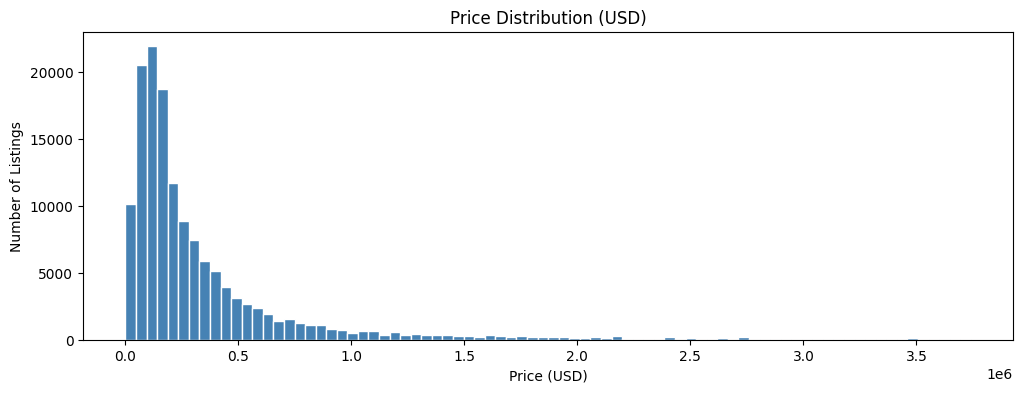

In [32]:
# Price distribution — raw scale
df['price_in_USD'].plot(
    kind='hist',
    bins=80,
    color='steelblue',
    edgecolor='white',
    title='Price Distribution (USD)',
    xlabel='Price (USD)',
    ylabel='Number of Listings',
    figsize=(12, 4)
);

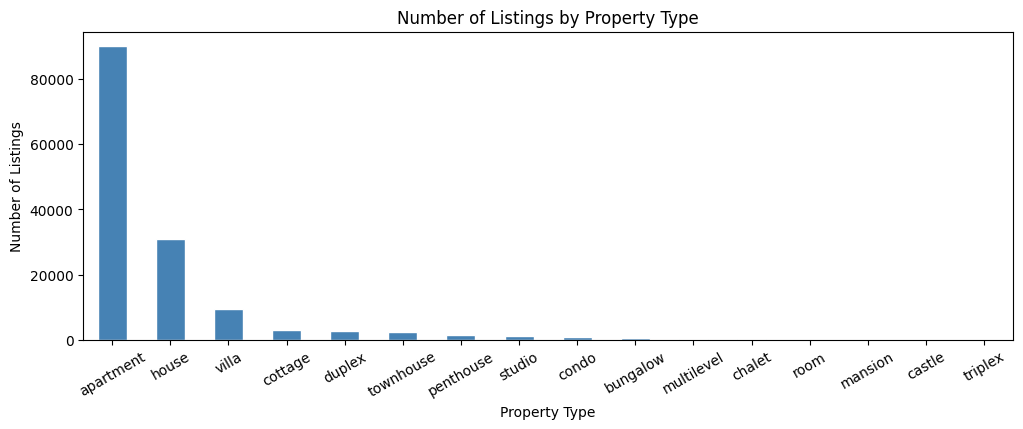

In [33]:
# Number of listings per property type
df['property_type'].value_counts().plot(
    kind='bar',
    color='steelblue',
    edgecolor='white',
    title='Number of Listings by Property Type',
    xlabel='Property Type',
    ylabel='Number of Listings',
    figsize=(12, 4),
    rot=30
);

In [34]:
df['property_type'].value_counts()

property_type
apartment     90099
house         31040
villa          9311
cottage        2876
duplex         2530
townhouse      2305
penthouse      1504
studio         1030
condo           841
bungalow        561
multilevel      108
chalet           97
room             46
mansion          21
castle            6
triplex           2
Name: count, dtype: int64

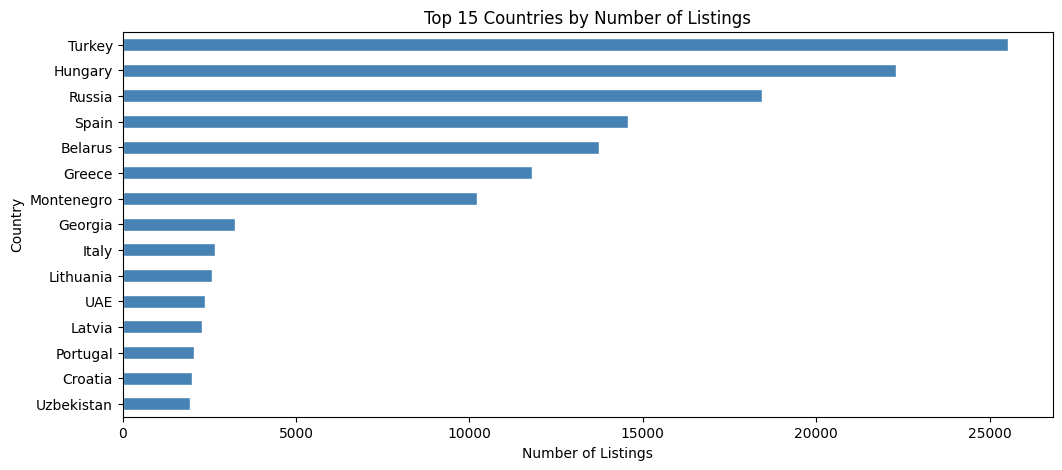

In [35]:
# Top 15 countries by listing count
df['country'].value_counts().head(15).sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='white',
    title='Top 15 Countries by Number of Listings',
    xlabel='Number of Listings',
    ylabel='Country',
    figsize=(12, 5)
);

## 6. Answering Business Questions

Now that the data is clean and we understand its structure, we answer the five business questions defined in the introduction.

### Question 1: Which countries have the highest and lowest median property prices?

We use **median** price and filter to countries with at least 100 listings to ensure reliability.

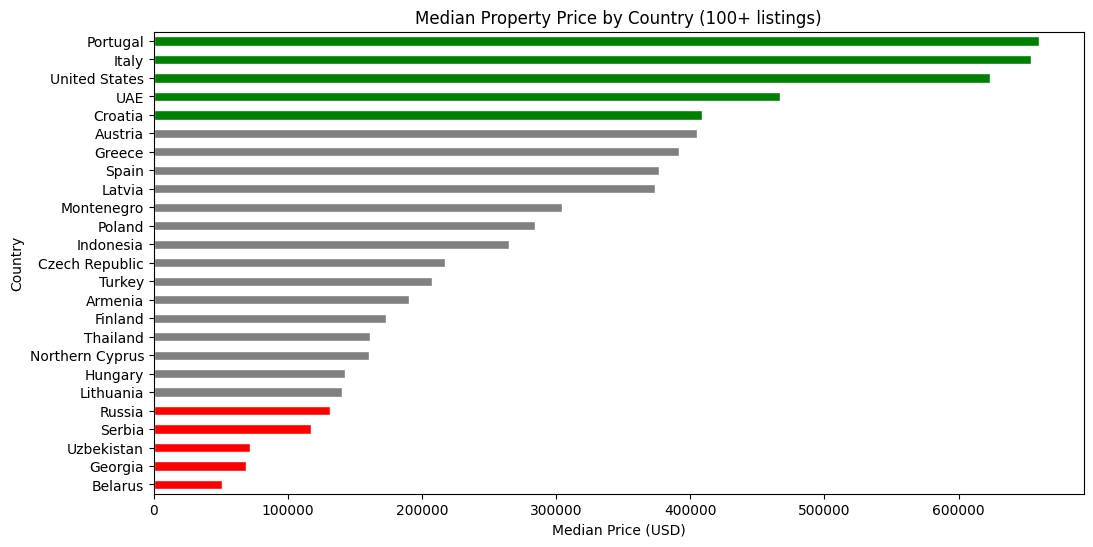

In [36]:
# Filter to countries with at least 100 listings
country_counts_all = df['country'].value_counts()
valid_countries = country_counts_all[country_counts_all >= 100].index
df_valid = df[df['country'].isin(valid_countries)]

# Median price per country
median_by_country = (
    df_valid.groupby('country')['price_in_USD']
    .median()
    .sort_values(ascending=True)
)

# Color top 5 green, bottom 5 red
colors = ['red'] * 5 + ['gray'] * (len(median_by_country) - 10) + ['green'] * 5

median_by_country.plot(
    kind='barh',
    color=colors,
    edgecolor='white',
    title='Median Property Price by Country (100+ listings)',
    xlabel='Median Price (USD)',
    ylabel='Country',
    figsize=(12, 6)
);

> Portugal, Italy, and the United States lead as the most expensive real estate markets with median prices exceeding 600,000 while Belarus and Georgia offer the most affordable entry points under 100,000. The data highlights a massive 13x price gap between the highest and lowest-ranked countries, illustrating significant global disparity in property valuation and purchasing power.

### Question 2: Which property types are the most expensive on Median?

We compare median prices across property types with at least 50 listings.

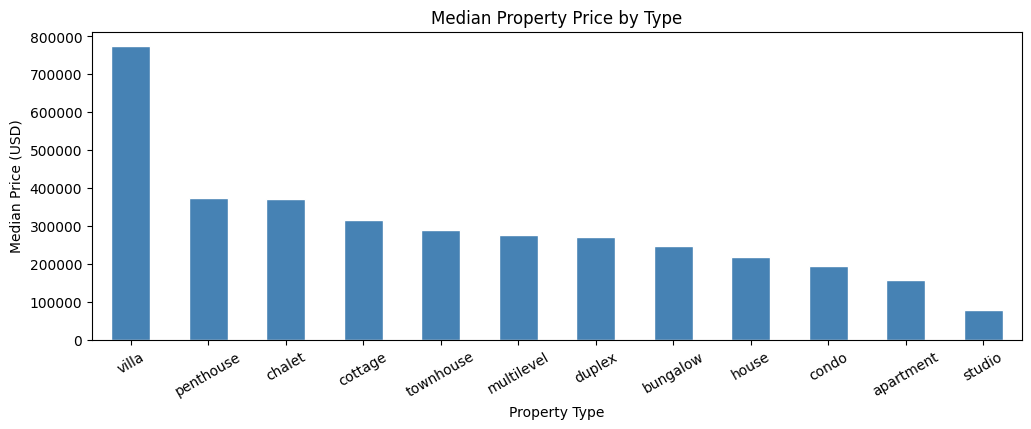

In [37]:
# Property types with at least 50 listings
valid_types = df['property_type'].value_counts()
valid_types = valid_types[valid_types >= 50].index

median_by_type = (
    df[df['property_type'].isin(valid_types)]
    .groupby('property_type')['price_in_USD']
    .median()
    .sort_values(ascending=False)
)

median_by_type.plot(
    kind='bar',
    color='steelblue',
    edgecolor='white',
    title='Median Property Price by Type',
    xlabel='Property Type',
    ylabel='Median Price (USD)',
    figsize=(12, 4),
    rot=30
);

> Villas represent the peak of the luxury market at approximately $775,000, costing more than double the next most expensive categories like penthouses or chalets. 

> The data reveals a massive affordability gap, with a single villa costing nearly ten times as much as a studio apartment, which remains the only category under $100,000.

### Question 3: Is there a relationship between living area and price?

We examine whether larger properties cost more using a scatter plot.

Pearson correlation: 0.6789865688031715


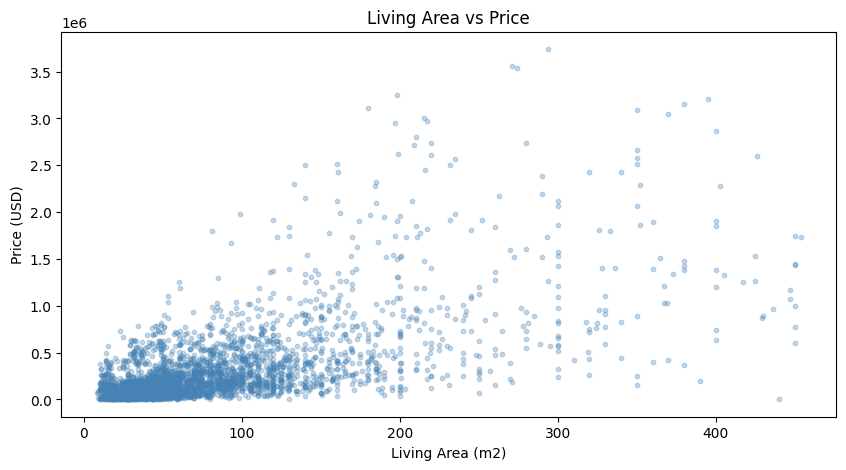

In [38]:
# Filter to rows with both living area and price
scatter_df = df[['apartment_living_area', 'price_in_USD']].dropna()

# Cap at 99th percentile to reduce visual noise
area_99 = scatter_df['apartment_living_area'].quantile(0.99)
scatter_df = scatter_df[scatter_df['apartment_living_area'] <= area_99]

# Sample for performance
sample = scatter_df.sample(min(5000, len(scatter_df)), random_state=42)

sample.plot(
    kind='scatter',
    x='apartment_living_area',
    y='price_in_USD',
    alpha=0.3,
    s=10,
    color='steelblue',
    title='Living Area vs Price',
    xlabel='Living Area (m2)',
    ylabel='Price (USD)',
    figsize=(10, 5)
)

corr = scatter_df['apartment_living_area'].corr(scatter_df['price_in_USD'])
print('Pearson correlation:' ,corr)

> Living area is a strong price driver, showing a positive Pearson correlation of 0.679, meaning that as square footage increases, property prices generally rise significantly.

### Question 4: Do newer buildings cost more than older ones?

We group properties by decade of construction and compare median prices.

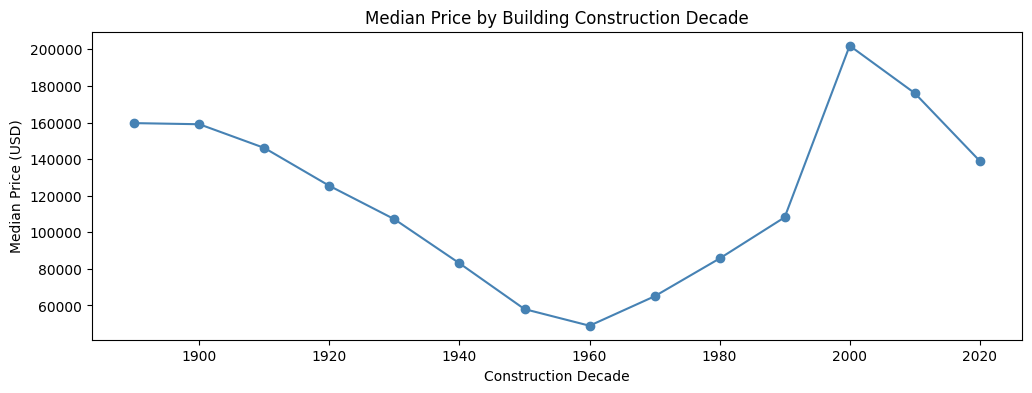

In [39]:
# Rows with valid construction year and price
age_df = df[['building_construction_year', 'price_in_USD']].dropna().copy()
age_df['decade'] = (age_df['building_construction_year'] // 10 * 10).astype(int)

# Keep decades with at least 50 listings
valid_decades = age_df['decade'].value_counts()
valid_decades = valid_decades[valid_decades >= 50].index
age_df = age_df[age_df['decade'].isin(valid_decades)]

decade_median = (
    age_df.groupby('decade')['price_in_USD']
    .median()
    .sort_index()
)

decade_median.plot(
    kind='line',
    marker='o',
    color='steelblue',
    title='Median Price by Building Construction Decade',
    xlabel='Construction Decade',
    ylabel='Median Price (USD)',
    figsize=(12, 4)
);

## Key Trends & Insights

The **"U-shape"** or **stair-step pattern** you usually see in this data (where newer homes and very old historic homes are more expensive than those built in the middle) is driven by three main factors:

### 1: The Modern Premium (2010s–Present)

Homes built in the last decade typically command the highest prices. This is due to:

- Modern building codes  
- Improved energy efficiency (insulation, HVAC systems)  
- Open-concept layouts  
- Fewer immediate maintenance needs (e.g., new roof, updated plumbing)

---

### 2️: The "Mid-Century Dip" (1960s–1980s)

You will often notice a **price valley** for homes built in this era. While often structurally sound, they frequently require expensive aesthetic and functional updates, such as:

- Removing popcorn ceilings  
- Replacing outdated electrical panels  
- Renovating smaller, closed-off floor plans  

---

### 3️: The Historic Value (Pre-1940s)

In many markets, very old homes (e.g., Victorian, Craftsman, Colonial styles) see a price rebound. These homes are valued for:

- Architectural character  
- Craftsmanship  
- Prime locations in established city centers  
- Scarcity of land in historic neighborhoods  

## Conclusion

This analysis explored **147,000 global real estate listings** to understand the key drivers of property prices worldwide.
Through systematic data cleaning and exploratory analysis, four major business questions were answered:

- **Location** is the most powerful price driver — median property prices vary dramatically across countries, meaning geography is the primary factor any investor must consider.
- **Property type** plays a significant role, with villas and penthouses commanding substantially higher prices compared to standard apartments and studios.
- **Size** has a clear positive relationship with price — larger living areas consistently correlate with higher prices, confirming that price per square meter is a reliable valuation metric across markets.
- **Building age** follows a U-shaped pattern: pre-1900s heritage properties and post-2000 modern builds hold the highest values, while mid-century homes from the 1950s–1960s represent the lowest-valued segment globally, due to their age, condition, and the era of mass construction they came from.

**Recommendations for investors and consulting clients:**

- Prioritize newer constructions (post-2000) in high-median countries for stronger returns.
- Focus on premium property types such as villas and penthouses in competitive markets.
- Approach mid-century properties cautiously — renovation and modernization costs can significantly erode returns.
- Future analysis could incorporate macroeconomic indicators such as GDP per capita and interest rates to build a more complete picture of global property valuations.